# Automotive Part Image-Text Matching

**Final Exam Submission Notebook — Step 011.4**

This executed notebook is the teacher-facing research narrative for the GitHub project. It uses committed validation evidence only. It does not train models, open the locked test split, authorize final evaluation, or change the retained production recipe.


## 1. Executive Summary

The project asks whether a photograph of an automotive part matches a short textual description. The task is intentionally more demanding than binary matching because it distinguishes a related but incorrect part from a completely unrelated one.

The retained multimodal neural network obtains **0.5333 validation accuracy** and **0.5208 macro F1** on the integrated group-isolated validation split. The central research conclusion is not that the model is perfect, but that combining image and text evidence is necessary and that the remaining errors are structured, measurable, and operationally meaningful.


In [1]:
from pathlib import Path
import ast
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path.cwd()
assert (ROOT / "README.md").is_file(), "Run the notebook from the repository root."

POLICY = {
    "model_training_performed": False,
    "locked_test_csv_files_opened": False,
    "test_split_used": False,
    "final_test_evaluation_authorized": False,
    "production_final_model_changed": False,
}
display(pd.DataFrame([POLICY]))


,model_training_performed,locked_test_csv_files_opened,test_split_used,final_test_evaluation_authorized,production_final_model_changed
0,False,False,False,False,False


## 2. Problem Statement and Real-World Motivation

Automotive catalogues, marketplaces, workshops, and inventory systems often need to determine whether a photograph and a short part description refer to the same component. A wrong result may waste staff time, route a part to the wrong catalogue entry, or produce a misleading search result.

The labels are:

- **MATCH** — image and text describe the same part category;
- **PARTIAL_MATCH** — the text names a different category in the same automotive system;
- **MISMATCH** — the text names a category from a different system.

The research hypothesis is that a multimodal model will outperform image-only and text-only approaches because the label is defined by the relationship between the two modalities.


## 3. Formal Task Definition and Evaluation Metrics

For image $I$, text $T$, and label $y \in \{M, P, X\}$, the classifier estimates

\[
p_\theta(y \mid I,T)=\operatorname{softmax}(f_\theta(I,T)).
\]

The main selection metric is macro F1:

\[
F1_{macro}=\frac{1}{3}\sum_{c \in \{M,P,X\}}\frac{2\,Precision_c\,Recall_c}{Precision_c+Recall_c}.
\]

Macro F1 is preferred because it gives equal importance to the difficult PARTIAL_MATCH class. Accuracy is reported as a complementary metric. All model selection uses the validation split only.


In [2]:
validation = pd.read_csv(ROOT / "data/processed/integrated_validation.csv")
summary = pd.DataFrame({
    "samples": [len(validation)],
    "part_groups": [validation["part_group_id"].nunique()],
    "images": [validation["image_id"].nunique()],
    "categories": [validation["part_category"].nunique()],
    "labels": [validation["label"].nunique()],
})
display(summary)
display(pd.crosstab(validation["source"], validation["label"]))


,samples,part_groups,images,categories,labels
0,60,20,20,10,3


label,MATCH,MISMATCH,PARTIAL_MATCH
source,,,
generated_development,10,10,10
wikimedia_commons_open_license,10,10,10


## 4. Previous Research

The project is situated between visual-semantic retrieval and multimodal classification. VSE++ studies image-text retrieval with hard negatives; VisualBERT combines visual regions and language in a transformer; CLIP learns transferable image-text representations at large scale. ResNet provides a standard residual vision backbone, while *Attention Is All You Need* motivates the sequence experiments. The evaluation design follows official scikit-learn definitions for precision, recall, F1, confusion matrices, and grouped validation.

The present project differs in three ways: the dataset is small and auditable, the target has an explicit same-system PARTIAL_MATCH class, and the final test split remains locked behind a one-shot authorization gate.


## 5. Data Acquisition, Licensing, Cleaning, and Grouped Splitting

The evidence combines deterministic development images and manually reviewed open-license Wikimedia Commons photographs. Every approved external image retains source, author, licence URL, and SHA-256 provenance. Images are decoded, normalized into reproducible files, and checked for duplicates and unsafe paths.

Rows are split by `part_group_id`, not independently. This prevents descriptions derived from the same physical image or part identity from crossing train and validation boundaries. The locked test CSV is not read by this notebook.


In [3]:
source_profile = (
    validation.groupby("source")
    .agg(samples=("sample_id", "count"), groups=("part_group_id", "nunique"), images=("image_id", "nunique"))
    .reset_index()
)
category_profile = (
    validation.groupby("part_category")["sample_id"]
    .count()
    .rename("validation_samples")
    .reset_index()
)
display(source_profile)
display(category_profile)


,source,samples,groups,images
0,generated_development,30,10,10
1,wikimedia_commons_open_license,30,10,10


,part_category,validation_samples
0,air_filter,6
1,alternator,6
2,brake_disc,6
3,brake_pad,6
4,coil_spring,6
5,headlight,6
6,oil_filter,6
7,shock_absorber,6
8,starter,6
9,taillight,6


## 6. Model Families and Experimental Design

The primary comparison contains a majority baseline, TF-IDF logistic regression, image-pixel logistic regression, Keras text and image models, and a Keras multimodal model. Additional controlled suites test Deep Learning fundamentals, sequence models, attention diagnostics, image representations, augmentation, compatibility scoring, ranking, and occlusion.

The course suites are evidence-generating experiments, not automatic replacements for the frozen production model. Pretrained downloads, fine-tuning, and human agreement remain behind explicit gates.


## 7. Integrated Validation Results

The multimodal model ranks first in the primary six-model comparison. The lower performance on the integrated real-plus-generated validation split compared with the generated-only development split is evidence of a harder and more realistic evaluation setting.


In [4]:
comparison = pd.read_csv(ROOT / "reports/integrated_training/validation_comparison.csv")
columns = [
    "validation_rank", "model", "input_modality",
    "integrated_validation_accuracy", "integrated_validation_macro_f1",
    "development_validation_macro_f1",
]
display(comparison[columns].sort_values("validation_rank"))


,validation_rank,model,input_modality,integrated_validation_accuracy,integrated_validation_macro_f1,development_validation_macro_f1
0,1,Keras Multimodal Neural Network,image_and_text,0.533333,0.520827,0.769591
1,2,TF-IDF + Logistic Regression,text,0.416667,0.329966,0.388889
2,3,Keras Text Neural Network,text,0.416667,0.329966,0.388889
3,4,Majority baseline,none,0.333333,0.166667,0.166667
4,5,Image pixels + Logistic Regression,image,0.333333,0.166667,0.166667
5,6,Keras Image Neural Network,image,0.333333,0.166667,0.166667


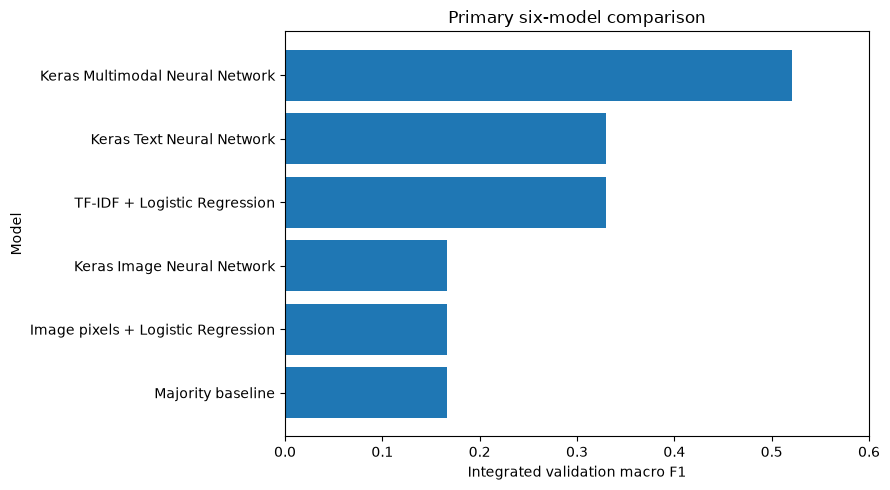

In [5]:
plot_data = comparison.sort_values("integrated_validation_macro_f1", ascending=True)
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(plot_data["model"], plot_data["integrated_validation_macro_f1"])
axis.set_xlabel("Integrated validation macro F1")
axis.set_ylabel("Model")
axis.set_title("Primary six-model comparison")
axis.set_xlim(0.0, 0.6)
figure.tight_layout()
plt.show()


## 8. Deep Learning Error Analysis and Failure Diagnostics

A strong exam project must explain failures, not only present its best score. The controlled reference analysis contains 35 errors among 60 validation samples. The key error mechanism is the collapse of PARTIAL_MATCH toward one of the two extreme classes. Real open-license images are harder than generated images, indicating domain shift rather than random noise.


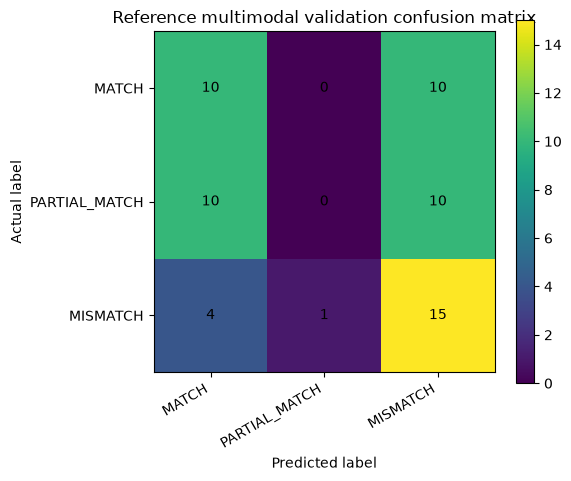

In [6]:
confusion = pd.read_csv(
    ROOT / "reports/validation_model_improvement/candidates/reference_multimodal/validation_confusion_matrix.csv",
    index_col=0,
)
figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(confusion.to_numpy())
axis.set_xticks(range(len(confusion.columns)))
axis.set_xticklabels([column.replace("predicted_", "") for column in confusion.columns], rotation=30, ha="right")
axis.set_yticks(range(len(confusion.index)))
axis.set_yticklabels([index.replace("actual_", "") for index in confusion.index])
axis.set_xlabel("Predicted label")
axis.set_ylabel("Actual label")
axis.set_title("Reference multimodal validation confusion matrix")
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        axis.text(column, row, str(int(confusion.iloc[row, column])), ha="center", va="center")
figure.colorbar(image, ax=axis)
figure.tight_layout()
plt.show()


In [7]:
with (ROOT / "reports/validation_model_improvement/validation_error_analysis.json").open(encoding="utf-8") as handle:
    error_summary = json.load(handle)

confusion_pairs = pd.DataFrame(
    [{"error_pair": pair, "count": count} for pair, count in error_summary["confusion_pairs"].items()]
).sort_values("count", ascending=False)
source_errors = pd.DataFrame(
    [{"source": source, **values} for source, values in error_summary["errors_by_source"].items()]
)
category_errors = pd.DataFrame(
    [{"category": category, **values} for category, values in error_summary["errors_by_category"].items()]
).sort_values(["error_rate", "category"], ascending=[False, True])
display(confusion_pairs)
display(source_errors)
display(category_errors)


,error_pair,count
0,PARTIAL_MATCH->MATCH,10
1,PARTIAL_MATCH->MISMATCH,10
2,MATCH->MISMATCH,10
3,MISMATCH->MATCH,4
4,MISMATCH->PARTIAL_MATCH,1


,source,errors,samples,error_rate
0,generated_development,15,30,0.500000
1,wikimedia_commons_open_license,20,30,0.666667


,category,errors,samples,error_rate
2,brake_disc,4,6,0.666667
5,headlight,4,6,0.666667
6,oil_filter,4,6,0.666667
7,shock_absorber,4,6,0.666667
8,starter,4,6,0.666667
0,air_filter,3,6,0.500000
1,alternator,3,6,0.500000
3,brake_pad,3,6,0.500000
4,coil_spring,3,6,0.500000
9,taillight,3,6,0.500000


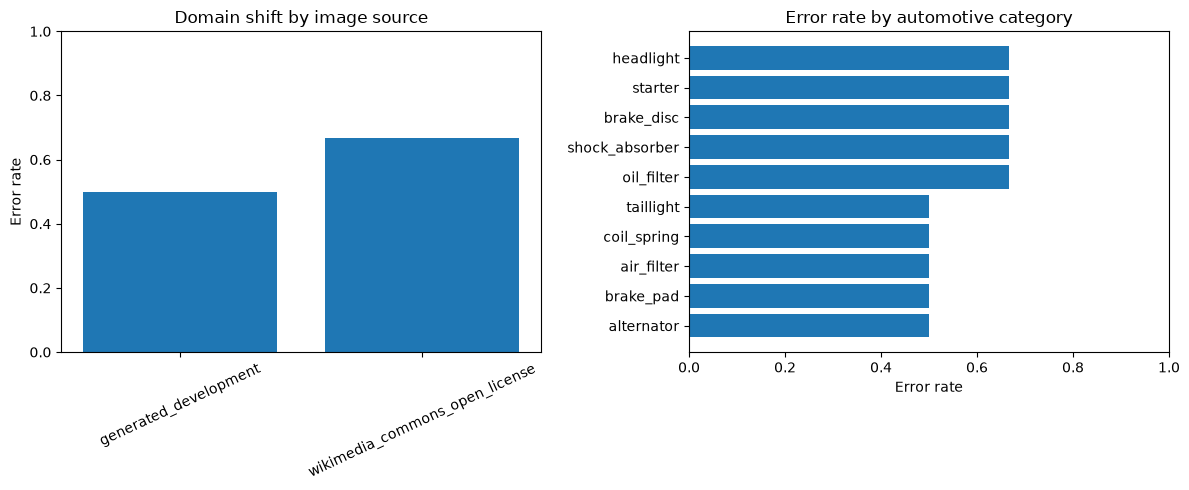

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(source_errors["source"], source_errors["error_rate"])
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Error rate")
axes[0].set_title("Domain shift by image source")
axes[0].tick_params(axis="x", rotation=25)
plot_categories = category_errors.sort_values("error_rate", ascending=True)
axes[1].barh(plot_categories["category"], plot_categories["error_rate"])
axes[1].set_xlim(0.0, 1.0)
axes[1].set_xlabel("Error rate")
axes[1].set_title("Error rate by automotive category")
figure.tight_layout()
plt.show()


,part_category,description,true_label,predicted_label,confidence,confidence_margin,source
0,brake_disc,Automotive brake pad set.,PARTIAL_MATCH,MATCH,0.414643,0.038981,generated_development
1,alternator,Automotive starter motor.,PARTIAL_MATCH,MISMATCH,0.408629,0.109929,generated_development
2,coil_spring,Automotive shock absorber.,PARTIAL_MATCH,MISMATCH,0.407800,0.111235,generated_development
3,headlight,Automotive headlight assembly.,MATCH,MISMATCH,0.405982,0.106261,generated_development
4,starter,Automotive starter motor.,MATCH,MISMATCH,0.405928,0.103951,generated_development
5,shock_absorber,Automotive shock absorber.,MATCH,MISMATCH,0.405768,0.106115,generated_development


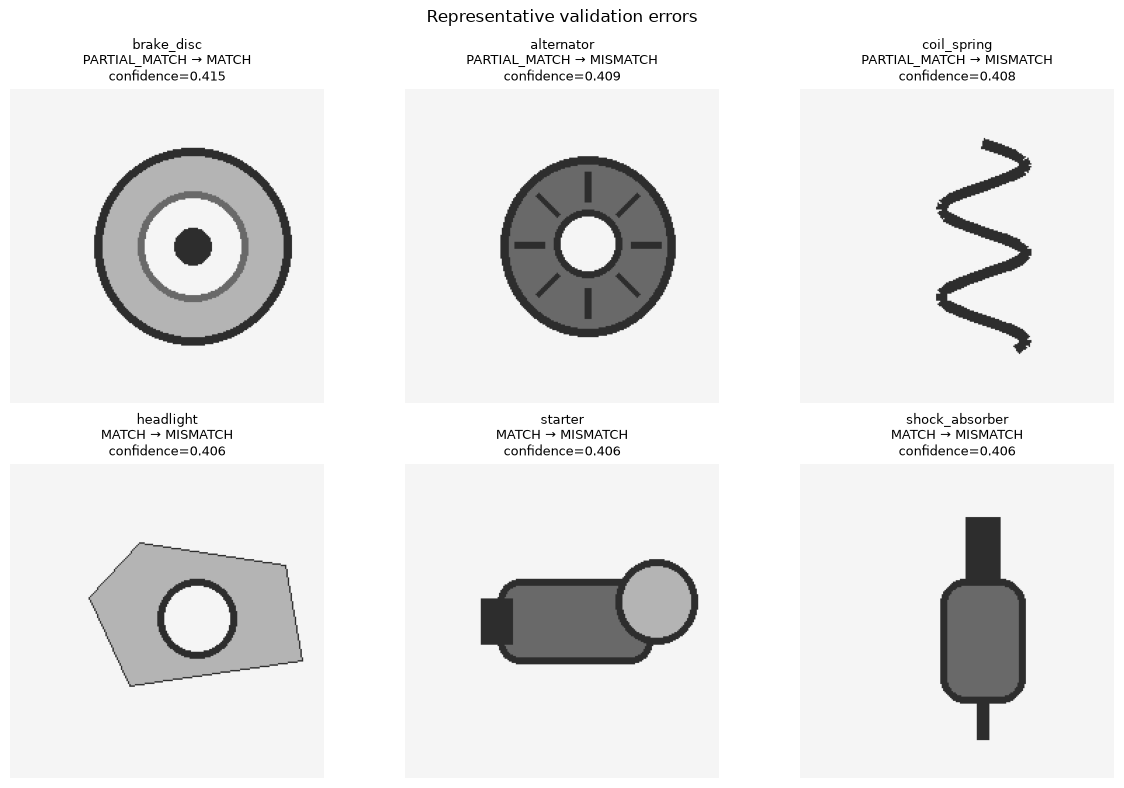

In [9]:
errors = pd.read_csv(ROOT / "reports/validation_model_improvement/validation_error_analysis.csv")
validation_lookup = validation[["image_id", "image_path"]].drop_duplicates("image_id")
examples = errors.merge(validation_lookup, on="image_id", how="left").head(6)

display(examples[[
    "part_category", "description", "true_label", "predicted_label",
    "confidence", "confidence_margin", "source",
]])

figure, axes = plt.subplots(2, 3, figsize=(12, 8))
for axis, (_, row) in zip(axes.flat, examples.iterrows()):
    image = Image.open(ROOT / row["image_path"]).convert("RGB")
    axis.imshow(image)
    axis.set_title(
        f"{row['part_category']}\n{row['true_label']} → {row['predicted_label']}\nconfidence={row['confidence']:.3f}",
        fontsize=9,
    )
    axis.axis("off")
figure.suptitle("Representative validation errors")
figure.tight_layout()
plt.show()


The absence of errors above confidence 0.60 is encouraging but does not prove calibration. It suggests that uncertain cases could be routed to human review. The project therefore treats the model as decision support, not as an unquestionable authority.

The Fundamentals suite also creates failures deliberately. This demonstrates that the author understands how preprocessing, learning rate, dropout, label alignment, activation choice, and optimizer updates affect training behavior.


,case,status,metric_name,metric_value,signature_detected,prevention
0,unscaled_images,OBSERVED,validation_macro_f1,1.666667e-01,True,Keep explicit image scaling in the model and a...
1,excessive_learning_rate,OBSERVED,validation_macro_f1,1.666667e-01,True,Use bounded predefined learning rates and term...
2,tiny_learning_rate,OBSERVED,validation_macro_f1,2.558008e-01,True,Track loss reduction and reject configurations...
3,excessive_dropout,OBSERVED,validation_macro_f1,1.666667e-01,True,Treat dropout as a tuned regularizer rather th...
4,misaligned_train_labels,OBSERVED,validation_macro_f1,2.667734e-01,True,Verify sample IDs and labels before every shuf...
5,sigmoid_activation,NO_STRONG_SIGNATURE,validation_macro_f1,2.401961e-01,False,Compare timing and gradients; prefer ReLU-like...
6,deep_sigmoid_gradient_probe,OBSERVED,first_to_last_kernel_gradient_ratio,6.806216e-07,True,"Prefer ReLU-like activations, normalization, a..."
7,missing_optimizer_step_probe,OBSERVED,absolute_loss_change_without_update,9.859562e-02,True,Use model.fit/train_on_batch or a reviewed cus...
8,validation_training_blocked,BLOCKED_BY_DESIGN,validation_used_for_weight_updates,0.000000e+00,True,Keep the split paths fixed in configuration an...


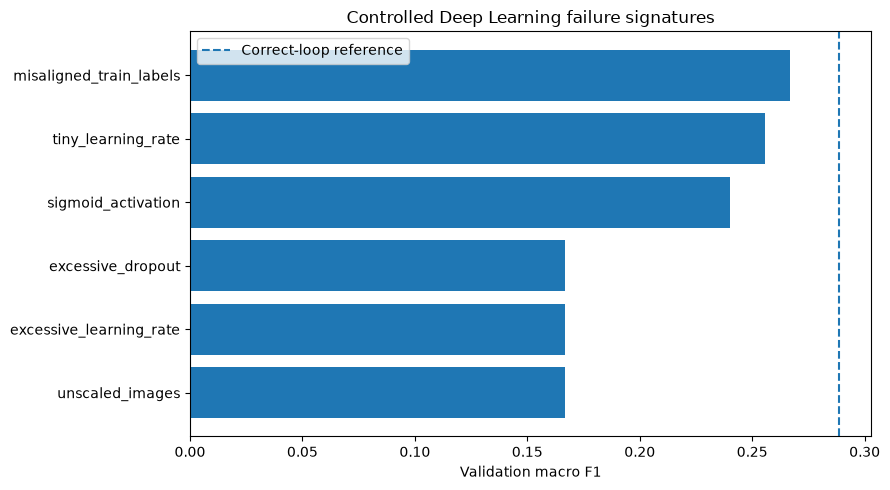

In [10]:
failures = pd.read_csv(ROOT / "reports/course_coverage/fundamentals/failure_diagnostics.csv")
validation_failures = failures[failures["metric_name"] == "validation_macro_f1"].copy()
display(failures[["case", "status", "metric_name", "metric_value", "signature_detected", "prevention"]])

plot_failures = validation_failures.sort_values("metric_value", ascending=True)
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(plot_failures["case"], plot_failures["metric_value"])
axis.axvline(0.2886, linestyle="--", label="Correct-loop reference")
axis.set_xlabel("Validation macro F1")
axis.set_title("Controlled Deep Learning failure signatures")
axis.legend()
figure.tight_layout()
plt.show()


## 9. Course Exercise Evidence: Fundamentals, Sequence, and Vision

- **Deep Learning Fundamentals:** 10/10 problems and 35 recorded training runs.
- **Transformers and Sequence Modelling:** 9 core problems and 21 recorded runs; the pretrained-transformer task remains gated.
- **Vision Core:** 6 completed problems and 48 recorded runs; pretrained backbone, fine-tuning, and genuine human annotation remain gated.

These suites explain why more complex models do not automatically win on a small dataset. The best text-only result remains close to a classical TF-IDF baseline because the relationship label cannot be inferred reliably from text without the image. Vision scoring and ranking are promising, but they are separate validation tasks and do not overwrite the frozen three-class model.


,suite,completed,training_runs,gated
0,Fundamentals,10,35,0
1,Sequence,9,21,1
2,Vision core,6,48,3


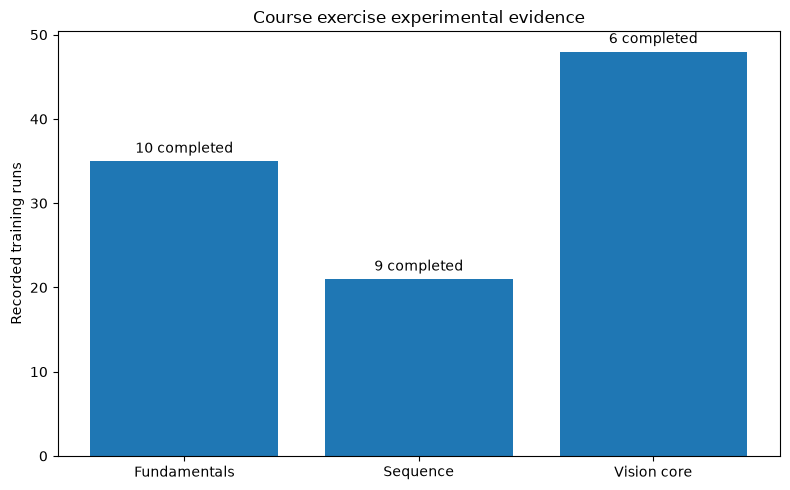

In [11]:
with (ROOT / "reports/course_coverage/fundamentals/fundamentals_suite_status.json").open(encoding="utf-8") as handle:
    fundamentals_status = json.load(handle)
with (ROOT / "reports/course_coverage/sequence/sequence_suite_status.json").open(encoding="utf-8") as handle:
    sequence_status = json.load(handle)
with (ROOT / "reports/course_coverage/vision/vision_suite_status.json").open(encoding="utf-8") as handle:
    vision_status = json.load(handle)

suite_summary = pd.DataFrame([
    {"suite": "Fundamentals", "completed": fundamentals_status.get("completed_exercise_problem_count", 10), "training_runs": fundamentals_status["run_count"], "gated": 0},
    {"suite": "Sequence", "completed": sequence_status.get("completed_core_problem_count", 9), "training_runs": sequence_status["training_runs_recorded"], "gated": len(sequence_status.get("deferred_problem_ids", []))},
    {"suite": "Vision core", "completed": vision_status["completed_problem_count"], "training_runs": vision_status["training_runs_recorded"], "gated": vision_status["deferred_problem_count"]},
])
display(suite_summary)

figure, axis = plt.subplots(figsize=(8, 5))
axis.bar(suite_summary["suite"], suite_summary["training_runs"])
for index, row in suite_summary.iterrows():
    axis.text(index, row["training_runs"] + 1, f"{int(row['completed'])} completed", ha="center")
axis.set_ylabel("Recorded training runs")
axis.set_title("Course exercise experimental evidence")
figure.tight_layout()
plt.show()


,experiment_id,run_id,family,variant,seed,status,parameter_count,epochs_completed,best_epoch,training_time_seconds,...,final_train_loss,final_validation_loss,generalization_gap,notes,selected_run_id,run_count,mean_macro_f1,std_macro_f1,per_class_f1,per_class_support
0,SEQ-005,tfidf-ngram-1-1-c-1,tfidf_logistic,ngram-1-1-c-1,42,COMPLETED,63,1,1,0.004235,...,NaN,NaN,0.000000,TF-IDF vocabulary=20; classical baseline.,tfidf-ngram-1-1-c-1,6,0.329966,0.000000,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.444444444444...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
1,SEQ-006,textcnn-seed-44,textcnn,textcnn,44,COMPLETED,3755,3,3,0.980802,...,1.096101,1.095744,0.022222,Keras sequence model; train/validation only.,textcnn-seed-44,3,0.306079,0.016331,"{""MATCH"": 0.16, ""PARTIAL_MATCH"": 0.27586206896...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
2,SEQ-004,embedding_average-seed-42,embedding_average,embedding_average,42,COMPLETED,1227,3,3,0.679597,...,1.097895,1.098391,0.027778,Keras sequence model; train/validation only.,embedding_average-seed-42,3,0.235697,0.051837,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.456140350877...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
3,SEQ-007,transformer-seed-43,transformer,transformer,43,COMPLETED,5499,3,3,1.507147,...,1.321886,1.096155,-0.011111,Keras sequence model; train/validation only.,transformer-seed-43,3,0.226391,0.042819,"{""MATCH"": 0.41379310344827586, ""PARTIAL_MATCH""...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
4,SEQ-006,gru-seed-42,gru,gru,42,COMPLETED,5175,3,2,1.007726,...,1.099188,1.098619,-0.005556,Keras sequence model; train/validation only.,gru-seed-42,3,0.175607,0.012644,"{""MATCH"": 0.4935064935064935, ""PARTIAL_MATCH"":...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
5,SEQ-006,lstm-seed-42,lstm,lstm,42,COMPLETED,6575,3,3,0.977365,...,1.098589,1.098560,0.011111,Keras sequence model; train/validation only.,lstm-seed-42,3,0.166667,0.000000,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.0, ""MISMATCH...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."


,augmentation_policy,run_count,validation_macro_f1_mean,validation_macro_f1_std,validation_accuracy_mean,validation_accuracy_std,feature_dimension,parameter_count,training_time_seconds_mean,inference_time_ms_mean,selected_configuration,macro_f1_delta_vs_none
0,combined,3,0.710000,0.028868,0.716667,0.028868,240,2410,0.023468,0.024752,True,0.050000
1,brightness,3,0.683492,0.025760,0.683333,0.028868,240,2410,0.024700,0.024372,False,0.023492
2,center_crop,3,0.682222,0.028350,0.683333,0.028868,240,2410,0.023766,0.027253,False,0.022222
3,jpeg_compression,3,0.660476,0.000000,0.650000,0.000000,240,2410,0.022776,0.026390,False,0.000476
4,none,3,0.660000,0.000000,0.650000,0.000000,240,2410,0.018377,0.024945,False,0.000000


,pairwise_ranking_accuracy,three_way_ordering_accuracy,equal_pair_accuracy,automated_foreground_alignment,human_review_claimed
0,0.883333,0.8,0.666667,0.75,False


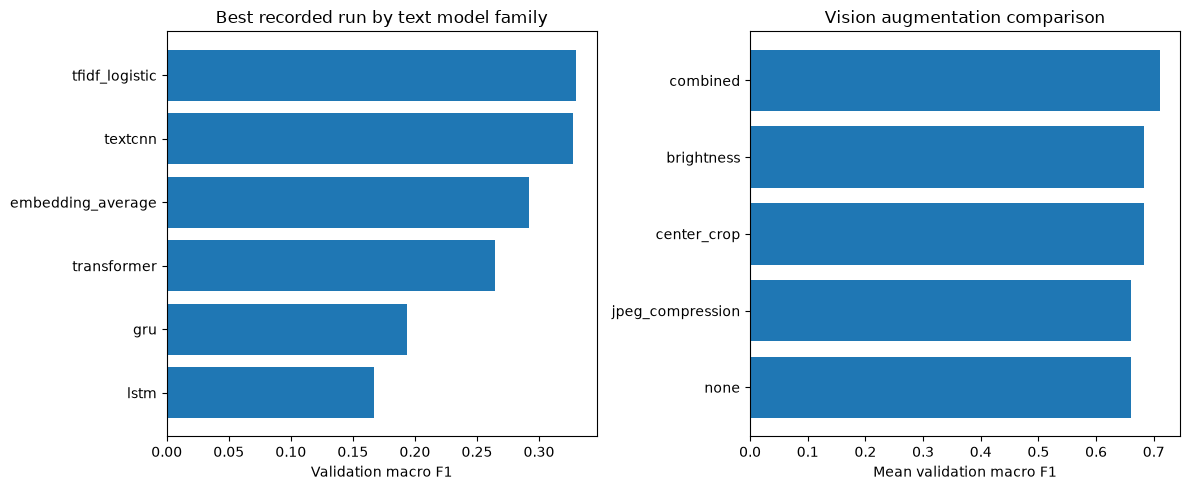

In [12]:
sequence_models = pd.read_csv(ROOT / "reports/course_coverage/sequence/model_comparison.csv")
vision_augmentation = pd.read_csv(ROOT / "reports/course_coverage/vision/augmentation_comparison.csv")
with (ROOT / "reports/course_coverage/vision/ranking_metrics.json").open(encoding="utf-8") as handle:
    ranking = json.load(handle)
with (ROOT / "reports/course_coverage/vision/explainability_summary.json").open(encoding="utf-8") as handle:
    explainability = json.load(handle)

display(sequence_models.sort_values("validation_macro_f1", ascending=False).head(8))
display(vision_augmentation.sort_values("validation_macro_f1_mean", ascending=False))
display(pd.DataFrame([{
    "pairwise_ranking_accuracy": ranking["pairwise_ranking_accuracy"],
    "three_way_ordering_accuracy": ranking["three_way_ordering_accuracy"],
    "equal_pair_accuracy": ranking["equal_pair_accuracy"],
    "automated_foreground_alignment": explainability["automated_foreground_proxy_alignment_rate"],
    "human_review_claimed": explainability["manual_review_claimed"],
}]))

best_sequence = (
    sequence_models.sort_values("validation_macro_f1", ascending=False)
    .drop_duplicates("family")
    .sort_values("validation_macro_f1", ascending=True)
)
vision_plot = vision_augmentation.sort_values("validation_macro_f1_mean", ascending=True)
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(best_sequence["family"], best_sequence["validation_macro_f1"])
axes[0].set_xlabel("Validation macro F1")
axes[0].set_title("Best recorded run by text model family")
axes[1].barh(vision_plot["augmentation_policy"], vision_plot["validation_macro_f1_mean"])
axes[1].set_xlabel("Mean validation macro F1")
axes[1].set_title("Vision augmentation comparison")
figure.tight_layout()
plt.show()


## 10. Testing, Reproducibility, and Locked-Test Policy

The repository combines unit and integration tests with semantic verification modules, artifact manifests, deterministic seeds, pinned dependencies, rollback-aware patch application, and clean-clone verification. The notebook is rebuilt from committed reports and never calls a training function.

The final test split remains closed because repeated access would turn it into another validation set. A committed authorization artifact must be changed explicitly before a one-shot final evaluation can occur.


In [13]:
test_functions = 0
for path in sorted((ROOT / "tests").glob("test_*.py")):
    tree = ast.parse(path.read_text(encoding="utf-8-sig"))
    test_functions += sum(
        isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.name.startswith("test_")
        for node in tree.body
    )
verification_modules = sorted((ROOT / "src/verification").glob("*.py"))
verification_modules = [path for path in verification_modules if path.name != "__init__.py"]
reproducibility = pd.DataFrame([{
    "test_functions": test_functions,
    "verification_modules": len(verification_modules),
    "requirements_locked": (ROOT / "requirements-lock.txt").is_file(),
    "test_split_used": False,
    "final_test_authorized": False,
}])
display(reproducibility)


,test_functions,verification_modules,requirements_locked,test_split_used,final_test_authorized
0,357,27,True,False,False


## 11. Limitations, Ethics, and Legal Compliance

The principal limitations are dataset size, category coverage, and domain shift between generated and real images. Validation metrics have uncertainty because only 60 integrated validation samples are available. Pretrained backbones could improve representation quality, but downloads, licence capture, resource use, and fine-tuning are intentionally gated. Human agreement and human localization metrics are not simulated.

All committed external images have open-licence provenance. The project contains no malicious code, surveillance behavior, credential collection, or privacy-invasive functionality. The software is research code and not a safety-critical automated parts-identification system.


## 12. Self-Assessment Against the Exam Rubric

The self-assessment is deliberately evidence-based and conservative. Two points are reserved because automated occlusion is not a human localization study and because final oral communication and portal submission remain manual responsibilities.


In [14]:
rubric = pd.read_csv(ROOT / "reports/final_submission/rubric_evidence_matrix.csv")
display(rubric)
display(pd.DataFrame([{
    "self_assessed_total": int(rubric["self_assessed_points"].sum()),
    "maximum_total": int(rubric["maximum_points"].sum()),
}]))


,criterion,maximum_points,self_assessed_points,repository_evidence
0,Problem statement,10,10,Notebook Sections 1-3 define the real-life mat...
1,Layout,20,20,Executed English notebook with numbered sectio...
2,Code quality,20,20,"Reusable src modules, project CLI, semantic ve..."
3,Previous research,10,10,Six primary or official sources and explicit c...
4,Data,10,10,"Generated and approved open-license images, at..."
5,Testing,10,10,"Automated tests, project verifiers, clean-clon..."
6,Visualization,10,9,"Model comparison, confusion matrix, error-sour..."
7,Communication,10,9,"Teacher-facing notebook, self-assessment, subm..."


,self_assessed_total,maximum_total
0,98,100


## 13. Conclusions and Defense Summary

1. The multimodal model is the strongest primary model because the label depends on both image and text.
2. PARTIAL_MATCH is the central semantic difficulty and explains most structured confusion.
3. Real open-license images are harder than generated images, demonstrating domain shift.
4. Controlled failures show how common Deep Learning mistakes appear in metrics and gradients.
5. More complex sequence models do not automatically outperform classical text methods on small, context-incomplete data.
6. Vision scoring, ranking, augmentation, and occlusion provide additional evidence without changing the frozen production model.
7. The test split remains locked, preserving the validity of a future one-shot final evaluation.


## References

1. Faghri, F. et al. **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives.** BMVC, 2018. — Visual Semantic Embedding.
2. Li, L. H. et al. **VisualBERT: A Simple and Performant Baseline for Vision and Language.** 2019.
3. Radford, A. et al. **Learning Transferable Visual Models From Natural Language Supervision.** ICML, 2021.
4. He, K. et al. **Deep Residual Learning for Image Recognition.** CVPR, 2016.
5. Vaswani, A. et al. **Attention Is All You Need.** NeurIPS, 2017.
6. **scikit-learn model evaluation documentation.** Official documentation for classification metrics and confusion matrices.

Repository evidence paths and exact experiment outputs are linked from the README, the submission checklist, and the `reports/` directory.
